# Initial Downloading, Wrangling, Loading, and Saving Data

To perform the RFM calculation, the data will first be downloaded and cleaned before being loaded for calculations.
Exploratory Data Analysis (EDA) will be performed on both datasets, tough the full dataset will get only surface-level check.

---

Online Retail II UCI – Dataset Features:
- Invoice – Invoice number (6-digit integral number uniquely assigned to each transaction. If starting with 'C', it indicates a cancellation)
- StockCode – Product (item) code (5-digit integral number uniquely assigned to each distinct product)
- Description – Product (item) name
- Quantity – The quantities of each product (item) per transaction
- InvoiceDate – Invoice date and time (the day and time when a transaction was generated)
- Price – Unit price (product price per unit in sterling £)
- Customer ID – Customer number (a 5-digit integral number uniquely assigned to each customer)
- Country – Country name (the name of the country where a customer resides)

### Initial Imports

In [1]:
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import squarify
import missingno as msno
from statsmodels.tsa.seasonal import STL


# Local src
from src.utils.eda_utils import clean_column_names, df_overview
from src.tasks.download import download
from src.config.constants import DOWNLOAD_PATH

print('Done')

Done


In [2]:
BG = "#FDFDFD"       
TEXT_COLOR = "#2B2D42"   
GRID_COLOR = "#E2E8F0"  

PINK = "#FF1493"
GREEN = "#00FF41"
PURPLE = "#D100D1"
ORANGERED = "#FF4500"
BLUE = "#1E90FF"
HOTPINK = "#FF69B4"
ORANGE = "#FFA500"
DARKVIOLET = "#9400D3"
TOMATO = "#FF6347"
LIMEGREEN = "#32CD32"
LIGHTSEAGREEN = "#20B2AA"

plt.rcParams.update({
    "savefig.dpi": 300,      
    "savefig.bbox": "tight", 
    
    # Background & colors
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": TEXT_COLOR,
    "axes.labelcolor": TEXT_COLOR,
    "xtick.color": TEXT_COLOR,
    "ytick.color": TEXT_COLOR,
    "axes.edgecolor": TEXT_COLOR,

    # Titles & labels
    "axes.titlesize": 18,
    "axes.titlepad": 16,
    "axes.labelsize": 13,
    "axes.labelpad": 10,
    "axes.labelweight": "medium",
    
    # Font
    "font.size": 12,
    "font.family": "Calibri",

    # Lines
    "lines.linewidth": 2.5,
    "lines.markersize": 7,    

    # Grid
    "axes.grid": True,
    "grid.color": GRID_COLOR,
    "grid.alpha": 0.6,   
    "grid.linewidth": 0.8,
    "grid.linestyle": "--",
    "axes.axisbelow": True,   

    # Figure
    "figure.figsize": (10, 6),
    "figure.autolayout": False,

    # Spines
    "axes.linewidth": 1.2,

    # Legend
    "legend.facecolor": "#f7f7f7",
    "legend.edgecolor": TEXT_COLOR,
    "legend.framealpha": 1.0,
    "legend.fontsize": 11,
    "legend.title_fontsize": 12,

    # Ticks
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.minor.visible": False,
    "ytick.minor.visible": False,
})

sns.set_theme(
    style="whitegrid", 
    context="notebook",  
)

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')
pd.set_option('display.max_colwidth', 100)
pd.set_option('display.expand_frame_repr', False)
pd.set_option('display.width', 120)
pd.set_option('display.precision', 3)

print('Done')

Done


## Data Acquisition

### Data Downloading and Loading

In [3]:
download(DOWNLOAD_PATH)

2026-04-26 13:05:39 | INFO    | src.tasks.download | Data exists in D:\projects\customer-rfm-segmentation-dashboard\data\01_raw. Skipping.


In [4]:
path_csv = '../data/01_raw/online_retail_II.csv'
df = pd.read_csv(path_csv)
df

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.950,"13,085.000",United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.750,"13,085.000",United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.750,"13,085.000",United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.100,"13,085.000",United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.250,"13,085.000",United Kingdom
...,...,...,...,...,...,...,...,...
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.100,"12,680.000",France
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.150,"12,680.000",France
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.150,"12,680.000",France
1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.950,"12,680.000",France


### Data Cleaning

In [5]:
df = clean_column_names(df)
df.columns

Index(['invoice', 'stock_code', 'description', 'quantity', 'invoice_date', 'price', 'customer_id', 'country'], dtype='object')

In [6]:
df_overview(df)

================================= Shape =================================
(1067371, 8)
================================= Info =================================
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column        Non-Null Count    Dtype  
---  ------        --------------    -----  
 0   invoice       1067371 non-null  object 
 1   stock_code    1067371 non-null  object 
 2   description   1062989 non-null  object 
 3   quantity      1067371 non-null  int64  
 4   invoice_date  1067371 non-null  object 
 5   price         1067371 non-null  float64
 6   customer_id   824364 non-null   float64
 7   country       1067371 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 65.1+ MB
None
================================= Columns =================================
Index(['invoice', 'stock_code', 'description', 'quantity', 'invoice_date', 'price', 'customer_id', 'country'], dtype='object')
=======

- It shows that price and quantity takes minus values in the dataset; 
- the column customer_id is float;
- the column invoice_date is object;
- 243k missing customer IDs and 4k of descriptions;
- negative values in price & quantity columns;
- 1m+ total records;
- quantities take large numbers 81k;
- 34k of duplicates;

In [7]:
print(df['customer_id'].isnull().sum() / df.shape[0])
print(df['description'].isnull().sum() / df.shape[0])

0.22766872999172733
0.0041054141437232225


- 22.8% of customer IDs are NaNs;
- 0.4% of descriptions are NaNs;

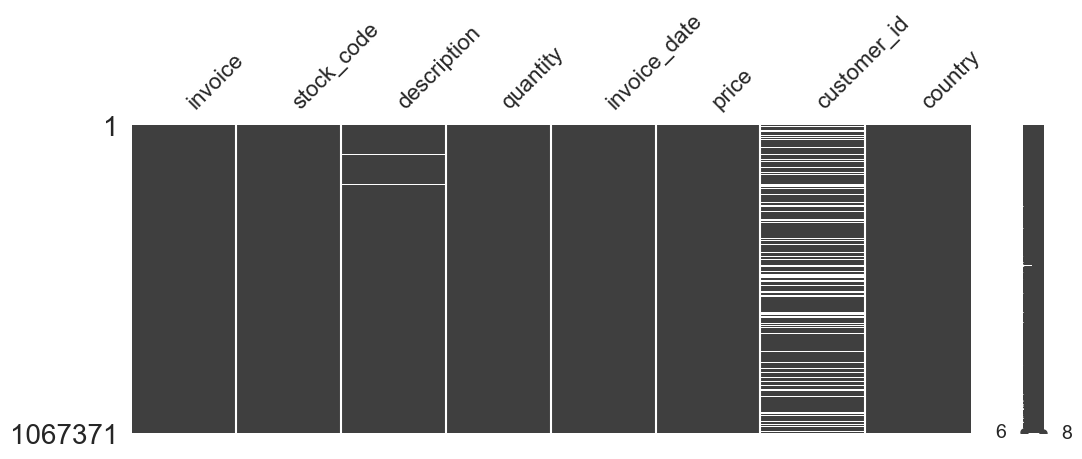

In [8]:
msno.matrix(df, figsize=(12, 4))
plt.show()

- the missing values in customer_id can be guests, as no pattern available;

### Analysis of Negative and Zero Values in Quantities & Prices

Check the frequency of negative or zero values in the dataset to determine their impact and decide on an appropriate handling strategy (e.g., removal or imputation).

In [9]:
print(df.loc[df['quantity'] < 0].shape)
print(df.loc[df['quantity'] == 0].shape)
print(df.loc[df['price'] < 0].shape)
print(df.loc[df['price'] == 0].shape)

(22950, 8)
(0, 8)
(5, 8)
(6202, 8)


- 23k of entries where quantity is negative; either logging/other issues or refunds
- 6k of entries where price is negative; probably logging/other issues

In [10]:
df.loc[df['quantity'] < 0, :]

,invoice,stock_code,description,quantity,invoice_date,price,customer_id,country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.950,"16,321.000",Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.650,"16,321.000",Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.250,"16,321.000",Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.100,"16,321.000",Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.950,"16,321.000",Australia
...,...,...,...,...,...,...,...,...
1065910,C581490,23144,ZINC T-LIGHT HOLDER STARS SMALL,-11,2011-12-09 09:57:00,0.830,"14,397.000",United Kingdom
1067002,C581499,M,Manual,-1,2011-12-09 10:28:00,224.690,"15,498.000",United Kingdom
1067176,C581568,21258,VICTORIAN SEWING BOX LARGE,-5,2011-12-09 11:57:00,10.950,"15,311.000",United Kingdom
1067177,C581569,84978,HANGING HEART JAR T-LIGHT HOLDER,-1,2011-12-09 11:58:00,1.250,"17,315.000",United Kingdom


- invoice starts with C in quantity < 0, can be mark of cancellation and return;

In [11]:
df.loc[(df['invoice'].str.startswith('C', na=False)) & (df['quantity'] > 0)]

,invoice,stock_code,description,quantity,invoice_date,price,customer_id,country
76799,C496350,M,Manual,1,2010-02-01 08:24:00,373.570,NaN,United Kingdom


- only one entry with C that has positive quantity;

In [12]:
df[df.duplicated(keep=False)].sort_values(by=list(df.columns))

,invoice,stock_code,description,quantity,invoice_date,price,customer_id,country
379,489517,21491,SET OF THREE VINTAGE GIFT WRAPS,1,2009-12-01 11:34:00,1.950,"16,329.000",United Kingdom
391,489517,21491,SET OF THREE VINTAGE GIFT WRAPS,1,2009-12-01 11:34:00,1.950,"16,329.000",United Kingdom
365,489517,21821,GLITTER STAR GARLAND WITH BELLS,1,2009-12-01 11:34:00,3.750,"16,329.000",United Kingdom
386,489517,21821,GLITTER STAR GARLAND WITH BELLS,1,2009-12-01 11:34:00,3.750,"16,329.000",United Kingdom
363,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.750,"16,329.000",United Kingdom
...,...,...,...,...,...,...,...,...
965610,C574510,22360,GLASS JAR ENGLISH CONFECTIONERY,-1,2011-11-04 13:25:00,2.950,"15,110.000",United Kingdom
986868,C575940,23309,SET OF 60 I LOVE LONDON CAKE CASES,-24,2011-11-13 11:38:00,0.550,"17,838.000",United Kingdom
986869,C575940,23309,SET OF 60 I LOVE LONDON CAKE CASES,-24,2011-11-13 11:38:00,0.550,"17,838.000",United Kingdom
1055441,C580764,22667,RECIPE BOX RETROSPOT,-12,2011-12-06 10:38:00,2.950,"14,562.000",United Kingdom


- duplicates can be due to logging issues.

In [13]:
#df = df[df['quantity'] > 0].copy()
df['invoice_date'] = pd.to_datetime(df['invoice_date'])
df['description'] = df['description'].str.strip()

- converted customer_id column type from float to int for sql loading;
- converted invoice_date column type to datetime for plotting;

In [14]:
print(f"Before: {len(df)}")
df = df[df['price'] != 0].copy()
df = df[df['price'] > 0].copy()
print(f"After dropping zero and negative prices: {len(df)}")

Before: 1067371
After dropping zero and negative prices: 1061164


- dropped negative and zero values from price column;

In [15]:
print(f"Before: {len(df)}")
df = df.dropna(subset=['customer_id'])
df['customer_id'] = df['customer_id'].astype(int)
print(f"After dropping null customer_id: {len(df)}")

Before: 1061164
After dropping null customer_id: 824293


- dropped empty customer_id columns, as they cannot be filled;

In [16]:
print(f"Before: {len(df)}")
df = df.drop(df.loc[(df['invoice'].str.startswith('C', na=False)) & (df['quantity'] > 0)].index).copy()
print(f"After dropping 'C' invoices with positive quantity: {len(df)}")

Before: 824293
After dropping 'C' invoices with positive quantity: 824293


- no difference as that transaction has not got any customer_id and has just been dropped by the very previous drop of null customer ids;

In [17]:
print(f"Before: {len(df)}")
df = df.drop_duplicates().copy()
print(f"After dropping duplicates: {len(df)}")

Before: 824293
After dropping duplicates: 797815


- dropped duplicates, as they are probably system log issues;

In [18]:
tmp = df.sort_values(by='price', ascending=False)
print(tmp['description'].head(5000).unique().tolist())
print(tmp['stock_code'].head(5000).unique().tolist())

['Manual', 'POSTAGE', 'Discount', 'DOTCOM POSTAGE', 'CRUK Commission', 'PICNIC BASKET WICKER 60 PIECES', 'Adjustment by john on 26/01/2010 17', 'Adjustment by Peter on 24/05/2010 1', 'Adjustment by Peter on Jun 25 2010', 'Adjustment by john on 26/01/2010 16', 'VINTAGE BLUE KITCHEN CABINET', 'VINTAGE RED KITCHEN CABINET', 'LOVE SEAT ANTIQUE WHITE METAL', 'RUSTIC  SEVENTEEN DRAWER SIDEBOARD', 'REGENCY MIRROR WITH SHUTTERS', 'GIANT SEVENTEEN DRAWER SIDEBOARD', 'CARRIAGE', 'BLUE KASHMIRI COFFEE TABLE', 'CHEST NATURAL WOOD 20 DRAWERS', 'FRENCH STYLE WALL DRESSER', 'ANT WHITE SWEETHEART TABLE W 3 DRAW', 'VINTAGE POST OFFICE CABINET', 'GREEN KASHMIRI OCCASIONAL TABLE', 'BLUE KASHMIRI OCCASIONAL TABLE', 'PINK KASHMIRI OCCASIONAL TABLE', 'SCHOOL DESK AND CHAIR', 'PINK PAINTED KASHMIRI TABLE', 'BLUE PAINTED KASHMIRI TABLE', 'PINK KASHMIRI COFFEE TABLE', 'DECORATIVE HANGING SHELVING UNIT', 'SET/3 COLOUR PAINTED KASHMIRI STOOL', 'BROCADE RING PURSE', 'HALL CABINET WITH 3 DRAWERS', 'BLUE PAINTED KA

- checked unique description & stock_code to identify invalid transactions for the analysis and modeling;
- adjustments, postage, manual, discount, dotcom postage, post, d, dot, adjust, m, cruk, c2, carriage, bank charges, amazonfee seem invalid;

In [19]:
df[df['stock_code'] == 'C2']

,invoice,stock_code,description,quantity,invoice_date,price,customer_id,country
9292,490127,C2,CARRIAGE,1,2009-12-03 18:13:00,50.000,14156,EIRE
14502,490542,C2,CARRIAGE,1,2009-12-07 09:42:00,50.000,14911,EIRE
19541,490998,C2,CARRIAGE,1,2009-12-08 17:24:00,50.000,16253,United Kingdom
22803,491160,C2,CARRIAGE,1,2009-12-10 10:29:00,50.000,14911,EIRE
32964,492092,C2,CARRIAGE,1,2009-12-15 14:03:00,50.000,14156,EIRE
...,...,...,...,...,...,...,...,...
1038663,579539,C2,CARRIAGE,1,2011-11-30 10:06:00,50.000,14911,EIRE
1040462,579768,C2,CARRIAGE,1,2011-11-30 15:08:00,50.000,14911,EIRE
1041945,579910,C2,CARRIAGE,1,2011-12-01 08:52:00,50.000,14911,EIRE
1044366,580127,C2,CARRIAGE,1,2011-12-01 17:51:00,50.000,14911,EIRE


- many rows with large prices are invalid, the amounts are large (outliers) and as they are not products, it is not suitable for analysis, calc and modeling;

In [20]:
non_product_keywords = [
    'manual', 
    'postage', 
    'dotcom postage', 
    'bank charges', 
    'amazon fee', 
    'discount',
    'adjust',
    'carriage'
]
non_product_codes = ['POST', 'DOT', 'M', 'D', 'C2', 'AMAZONFEE', 
                     'BANK CHARGES', 'CRUK']
print(f"Before: {len(df)}")
df = df[~df['stock_code'].isin(non_product_codes)]
print(f"After removing rows with non-product codes: {len(df)}")

additional_non_product_keywords = ['adjust']

print(f"Before: {len(df)}")
pattern = '|'.join(non_product_keywords)
df = df[~df['description'].str.lower().str.contains(pattern, na=False)].copy()
print(f"After removing rows with non-product descriptions: {len(df)}")

Before: 797815
After removing rows with non-product codes: 794261
Before: 794261
After removing rows with non-product descriptions: 794016


- dropped non-product transactions;

In [21]:
tmp = df.sort_values(by='quantity', ascending=False)
print(tmp[['description', 'stock_code', 'price', 'quantity']].head(50))
print(tmp[['description', 'stock_code', 'price', 'quantity']].tail(50))

                                 description stock_code  price  quantity
1065882          PAPER CRAFT , LITTLE BIRDIE      23843  2.080     80995
587080        MEDIUM CERAMIC TOP STORAGE JAR      23166  1.040     74215
90857     BLACK AND WHITE PAISLEY FLOWER MUG      37410  0.100     19152
127168           SET/6 WOODLAND PAPER PLATES      21091  0.100     12960
127166           SET/6 STRAWBERRY PAPER CUPS      21099  0.100     12960
127169             SET/6 WOODLAND PAPER CUPS      21085  0.100     12744
127167         SET/6 STRAWBERRY PAPER PLATES      21092  0.100     12480
135027       PACK OF 12 PINK PAISLEY TISSUES      21984  0.250     10000
135029         PACK OF 12 RED SPOTTY TISSUES      21980  0.250     10000
135028               PACK OF 12 SUKI TISSUES      21982  0.250     10000
135030           PACK OF 12 WOODLAND TISSUES      21981  0.250     10000
93677        SMALL FAIRY CAKE FRIDGE MAGNETS      85220  0.300      9456
432176   ROTATING SILVER ANGELS T-LIGHT HLDR      8

- huge positive & negative quantities are valid, as they capture regular purchases & returns;

In [22]:
df['revenue'] = df['quantity'] * df['price']
df.groupby('customer_id')['revenue'].sum().describe()

count     5,875.000
mean      2,784.032
std      13,798.791
min      -1,343.240
25%         328.000
50%         835.220
75%       2,164.280
max     578,408.640
Name: revenue, dtype: float64

- some of our customers are having negative revenue, probably data on their initial purchase was not collected, but return was; 
- the negative qty will be dropped for RFM calc, but can be left in the base dataset to preserve a possibility of conducting an analysis of cancellations;

In [23]:
tmp = df.groupby('customer_id')['revenue'].sum().reset_index()
negative_ids = tmp['customer_id'][tmp['revenue'] < 0]
print('Before:', len(df))
df = df[~df['customer_id'].isin(negative_ids)].copy()
print('After removing customers with negative revenue:', len(df))
df

Before: 794016
After removing customers with negative revenue: 793755


,invoice,stock_code,description,quantity,invoice_date,price,customer_id,country,revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.950,13085,United Kingdom,83.400
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.750,13085,United Kingdom,81.000
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.750,13085,United Kingdom,81.000
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.100,13085,United Kingdom,100.800
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.250,13085,United Kingdom,30.000
...,...,...,...,...,...,...,...,...,...
1067365,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.850,12680,France,10.200
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.100,12680,France,12.600
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.150,12680,France,16.600
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.150,12680,France,16.600


- dropped all transactions of customers that would have negative revenue balance in the monetary from the main df;

In [24]:
print(df[['country', 'revenue', 'invoice_date']].sort_values(by='invoice_date', ascending=False).head(50))
print(df[['country', 'revenue', 'invoice_date']].sort_values(by='invoice_date', ascending=False).tail(50))

                country  revenue        invoice_date
1067369          France   14.850 2011-12-09 12:50:00
1067362          France   15.600 2011-12-09 12:50:00
1067356          France   19.800 2011-12-09 12:50:00
1067357          France   19.800 2011-12-09 12:50:00
1067358          France   15.000 2011-12-09 12:50:00
1067359          France   15.000 2011-12-09 12:50:00
1067360          France   15.000 2011-12-09 12:50:00
1067361          France   15.000 2011-12-09 12:50:00
1067355          France   23.400 2011-12-09 12:50:00
1067363          France   23.400 2011-12-09 12:50:00
1067365          France   10.200 2011-12-09 12:50:00
1067366          France   12.600 2011-12-09 12:50:00
1067367          France   16.600 2011-12-09 12:50:00
1067368          France   16.600 2011-12-09 12:50:00
1067364          France   16.600 2011-12-09 12:50:00
1067353  United Kingdom  214.800 2011-12-09 12:49:00
1067352  United Kingdom   30.000 2011-12-09 12:49:00
1067351  United Kingdom   23.600 2011-12-09 12

- the records start and end smoothly, in Dec, right before New Year;

In [25]:
df['year'] = df['invoice_date'].dt.year
df['month'] = df['invoice_date'].dt.month
df['day'] = df['invoice_date'].dt.day
df['hour'] = df['invoice_date'].dt.hour
df['day_of_week'] = df['invoice_date'].dt.day_name()

print(df.columns)
df

Index(['invoice', 'stock_code', 'description', 'quantity', 'invoice_date', 'price', 'customer_id', 'country',
       'revenue', 'year', 'month', 'day', 'hour', 'day_of_week'],
      dtype='object')


,invoice,stock_code,description,quantity,invoice_date,price,customer_id,country,revenue,year,month,day,hour,day_of_week
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.950,13085,United Kingdom,83.400,2009,12,1,7,Tuesday
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.750,13085,United Kingdom,81.000,2009,12,1,7,Tuesday
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.750,13085,United Kingdom,81.000,2009,12,1,7,Tuesday
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.100,13085,United Kingdom,100.800,2009,12,1,7,Tuesday
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.250,13085,United Kingdom,30.000,2009,12,1,7,Tuesday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1067365,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.850,12680,France,10.200,2011,12,9,12,Friday
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.100,12680,France,12.600,2011,12,9,12,Friday
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.150,12680,France,16.600,2011,12,9,12,Friday
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.150,12680,France,16.600,2011,12,9,12,Friday


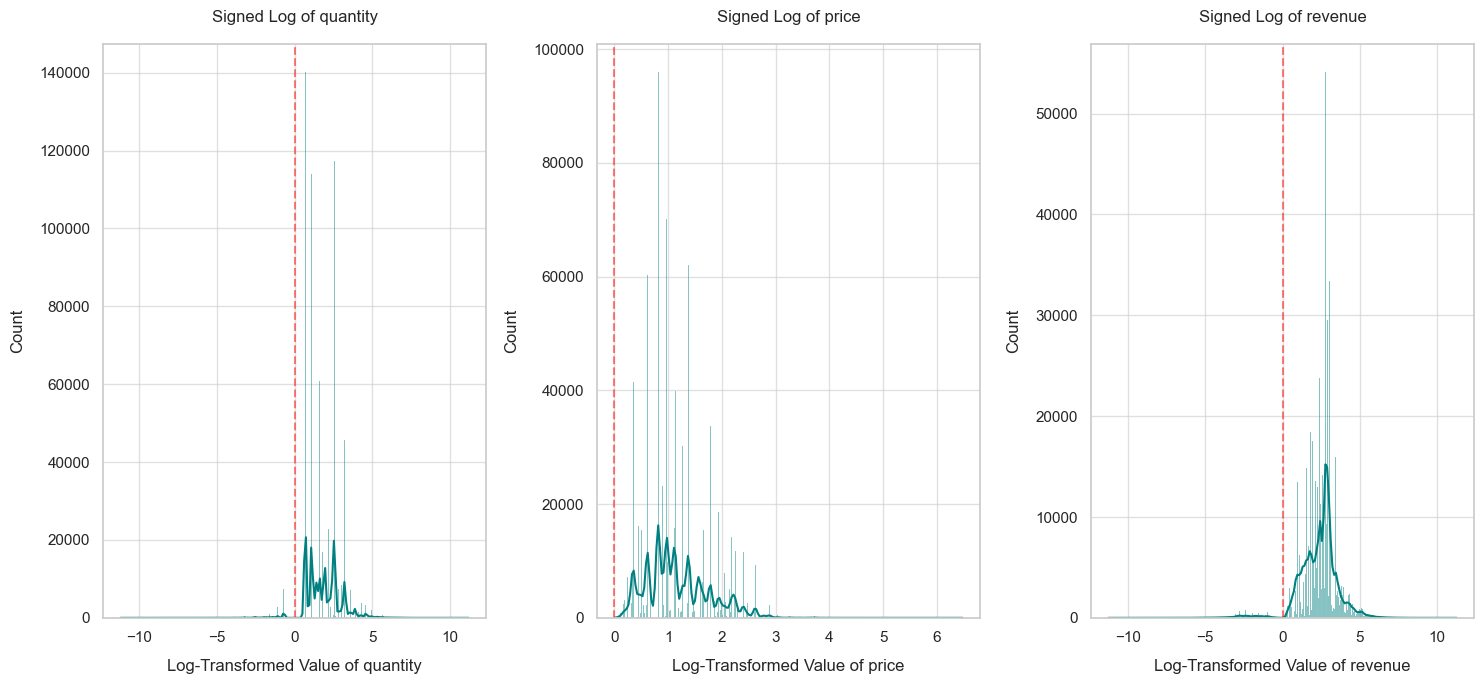

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(15, 7))

dist_cols = ['quantity', 'price', 'revenue']


for i, col in enumerate(dist_cols):
    log_data = np.sign(df[col]) * np.log1p(df[col].abs()) 
    
    sns.histplot(log_data, kde=True, ax=axes[i], color='teal')
    
    axes[i].axvline(0, color='red', linestyle='--', alpha=0.5)
    
    axes[i].set_title(f"Signed Log of {col}")
    axes[i].set_xlabel(f"Log-Transformed Value of {col}")

plt.tight_layout()
plt.show()

2026-04-26 13:06:02 | INFO    | matplotlib.category | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-04-26 13:06:03 | INFO    | matplotlib.category | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


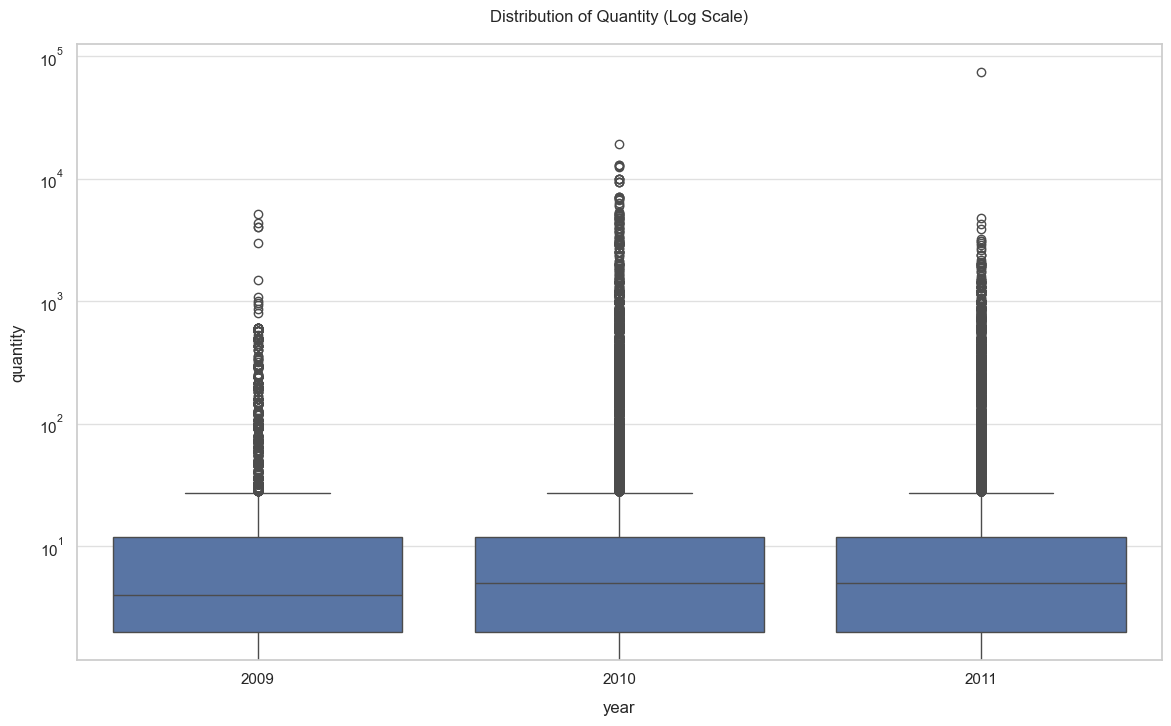

In [27]:
plt.figure(figsize=(14, 8))
ax = sns.boxplot(x='year', y='quantity', data=df)

ax.set_yscale("log") 

plt.title('Distribution of Quantity (Log Scale)')
plt.show()

- see the consistency in order sizes across years (50% of all is 2-12 units per order);

2026-04-26 13:06:04 | INFO    | matplotlib.category | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-04-26 13:06:05 | INFO    | matplotlib.category | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


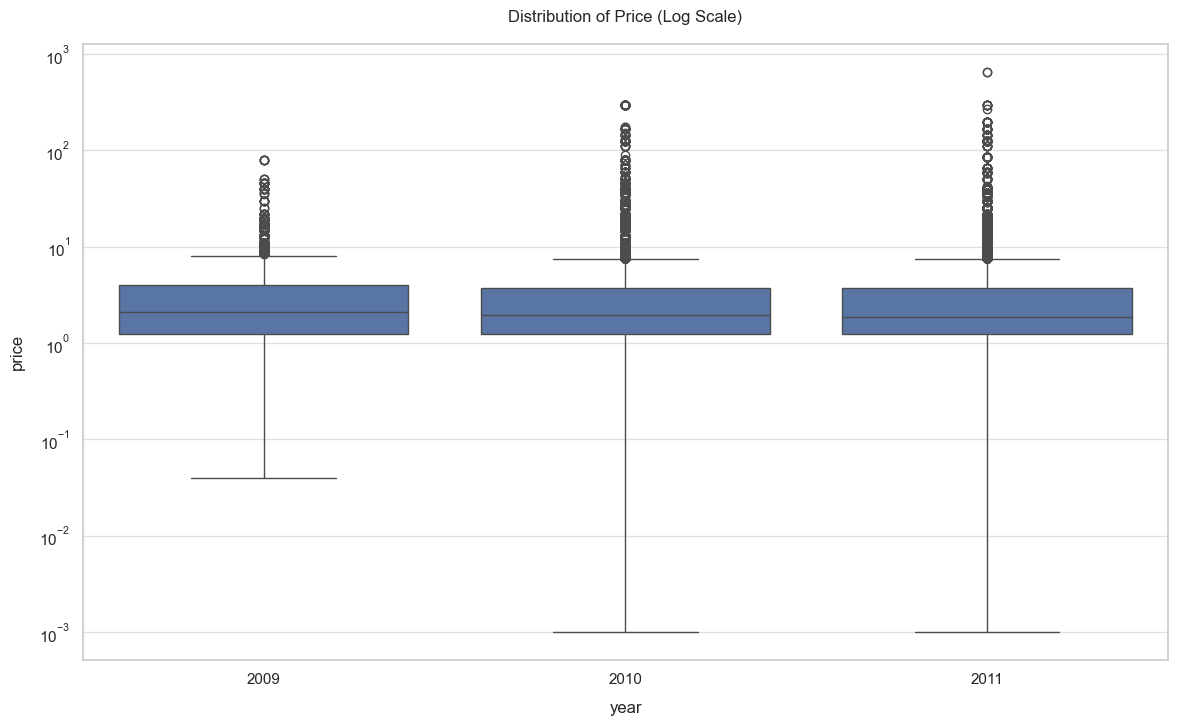

In [28]:
plt.figure(figsize=(14, 8))
ax = sns.boxplot(x='year', y='price', data=df)

ax.set_yscale("log") 

plt.title('Distribution of Price (Log Scale)')
plt.show()

- see a lot of outliers, but can be used NTILE (SQL) and qcut (pandas) to handle them when calculating rfm; (monetary will be huge and without handling it only the big players will be marked as valuable);

2026-04-26 13:06:06 | INFO    | matplotlib.category | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-04-26 13:06:06 | INFO    | matplotlib.category | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


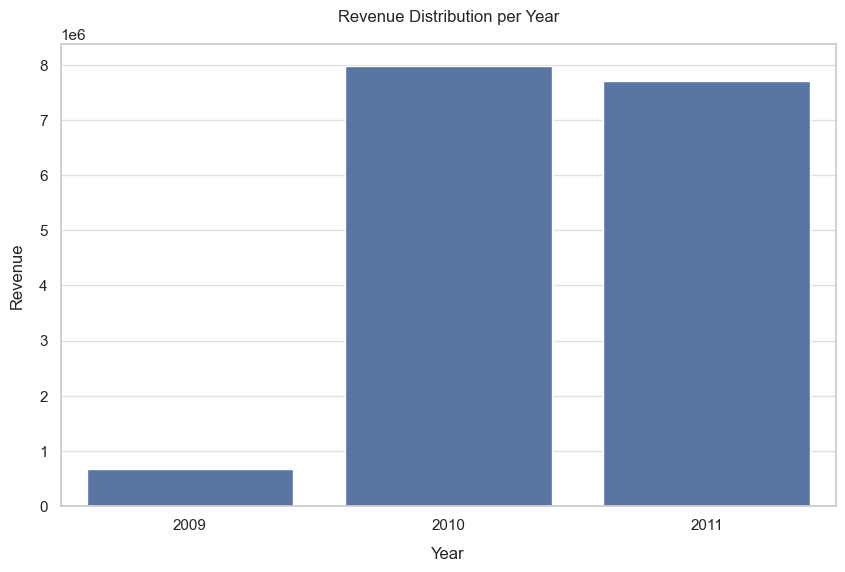

In [29]:
year_rev = df.groupby('year')['revenue'].sum()

sns.barplot(x=year_rev.index, y=year_rev.values)
plt.title('Revenue Distribution per Year')
plt.xlabel('Year')
plt.ylabel('Revenue')
plt.show()

- the total revenue are roughly the same for 2010 (1) and 2011 (2);
- the 2009 revenue is not captured well in the records;

2026-04-26 13:06:06 | INFO    | matplotlib.category | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-04-26 13:06:06 | INFO    | matplotlib.category | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


Text(0.5, 1.0, 'Monthly Revenue Trend')

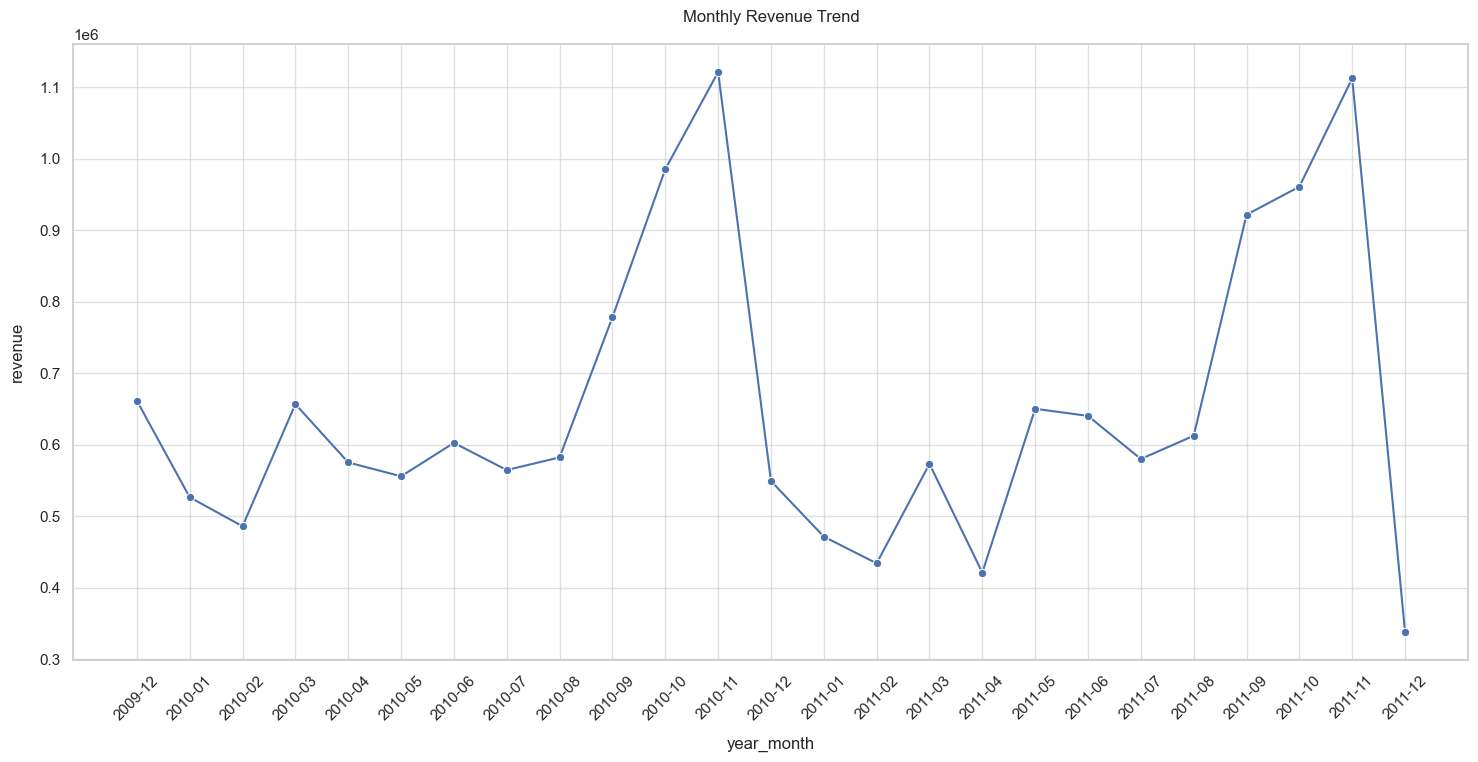

In [30]:
year_month_rev = df.groupby(['year','month'])['revenue'].sum().reset_index()
year_month_rev['year_month'] = year_month_rev['year'].astype(str) + '-' + year_month_rev['month'].astype(str).str.zfill(2)
year_month_rev = year_month_rev.sort_values('year_month')

plt.figure(figsize=(18, 8))
sns.lineplot(data=year_month_rev, x='year_month', y='revenue', marker='o')
plt.xticks(rotation=45)
plt.title('Monthly Revenue Trend')

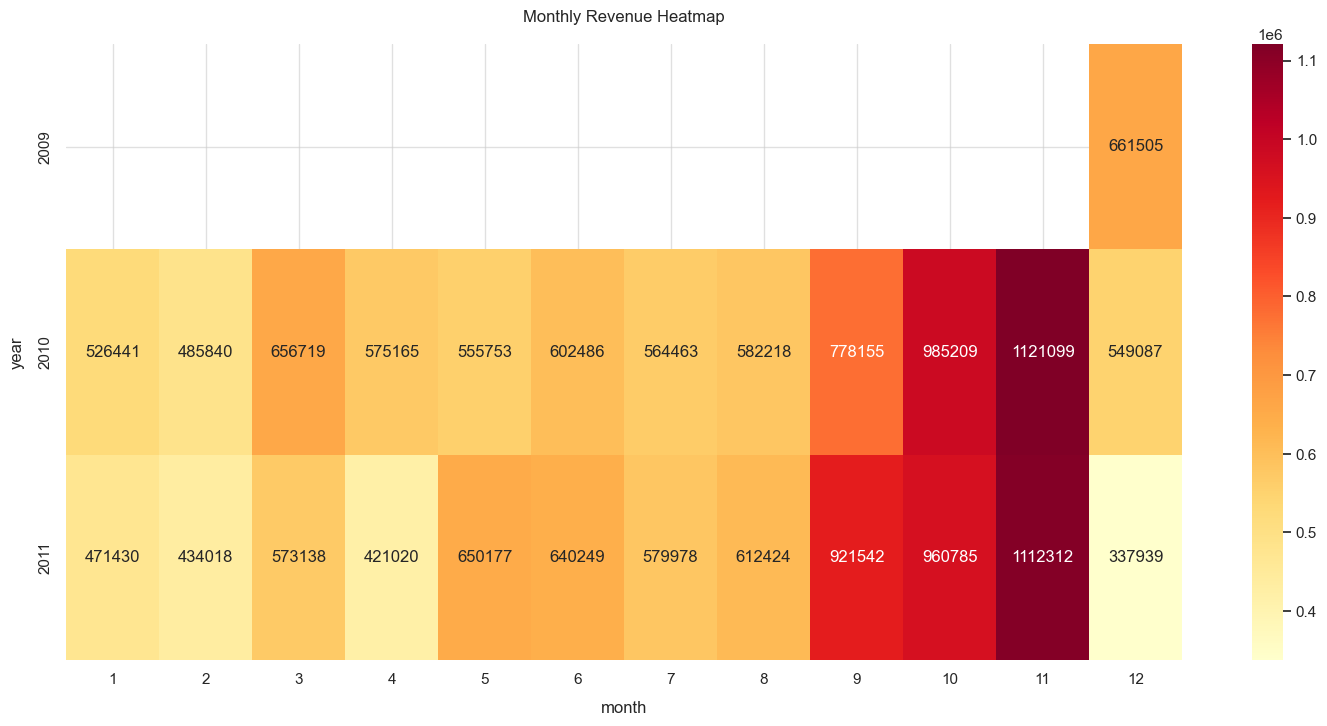

In [31]:
pivot_rev = year_month_rev.pivot(index='year', columns='month', values='revenue')

plt.figure(figsize=(18, 8))
sns.heatmap(pivot_rev, annot=True, fmt=".0f", cmap="YlOrRd")
plt.title('Monthly Revenue Heatmap')
plt.show()

- see 2 spikes of monthly revenue in Oct-Nov in years 2010 and 2011; can be due to purchases before New Year; (pre-holiday surge)
- see 2 huge drop of monthly revenue in Dec in years 2010 and 2011;
- want to compare with day of month revenue heatmaps;

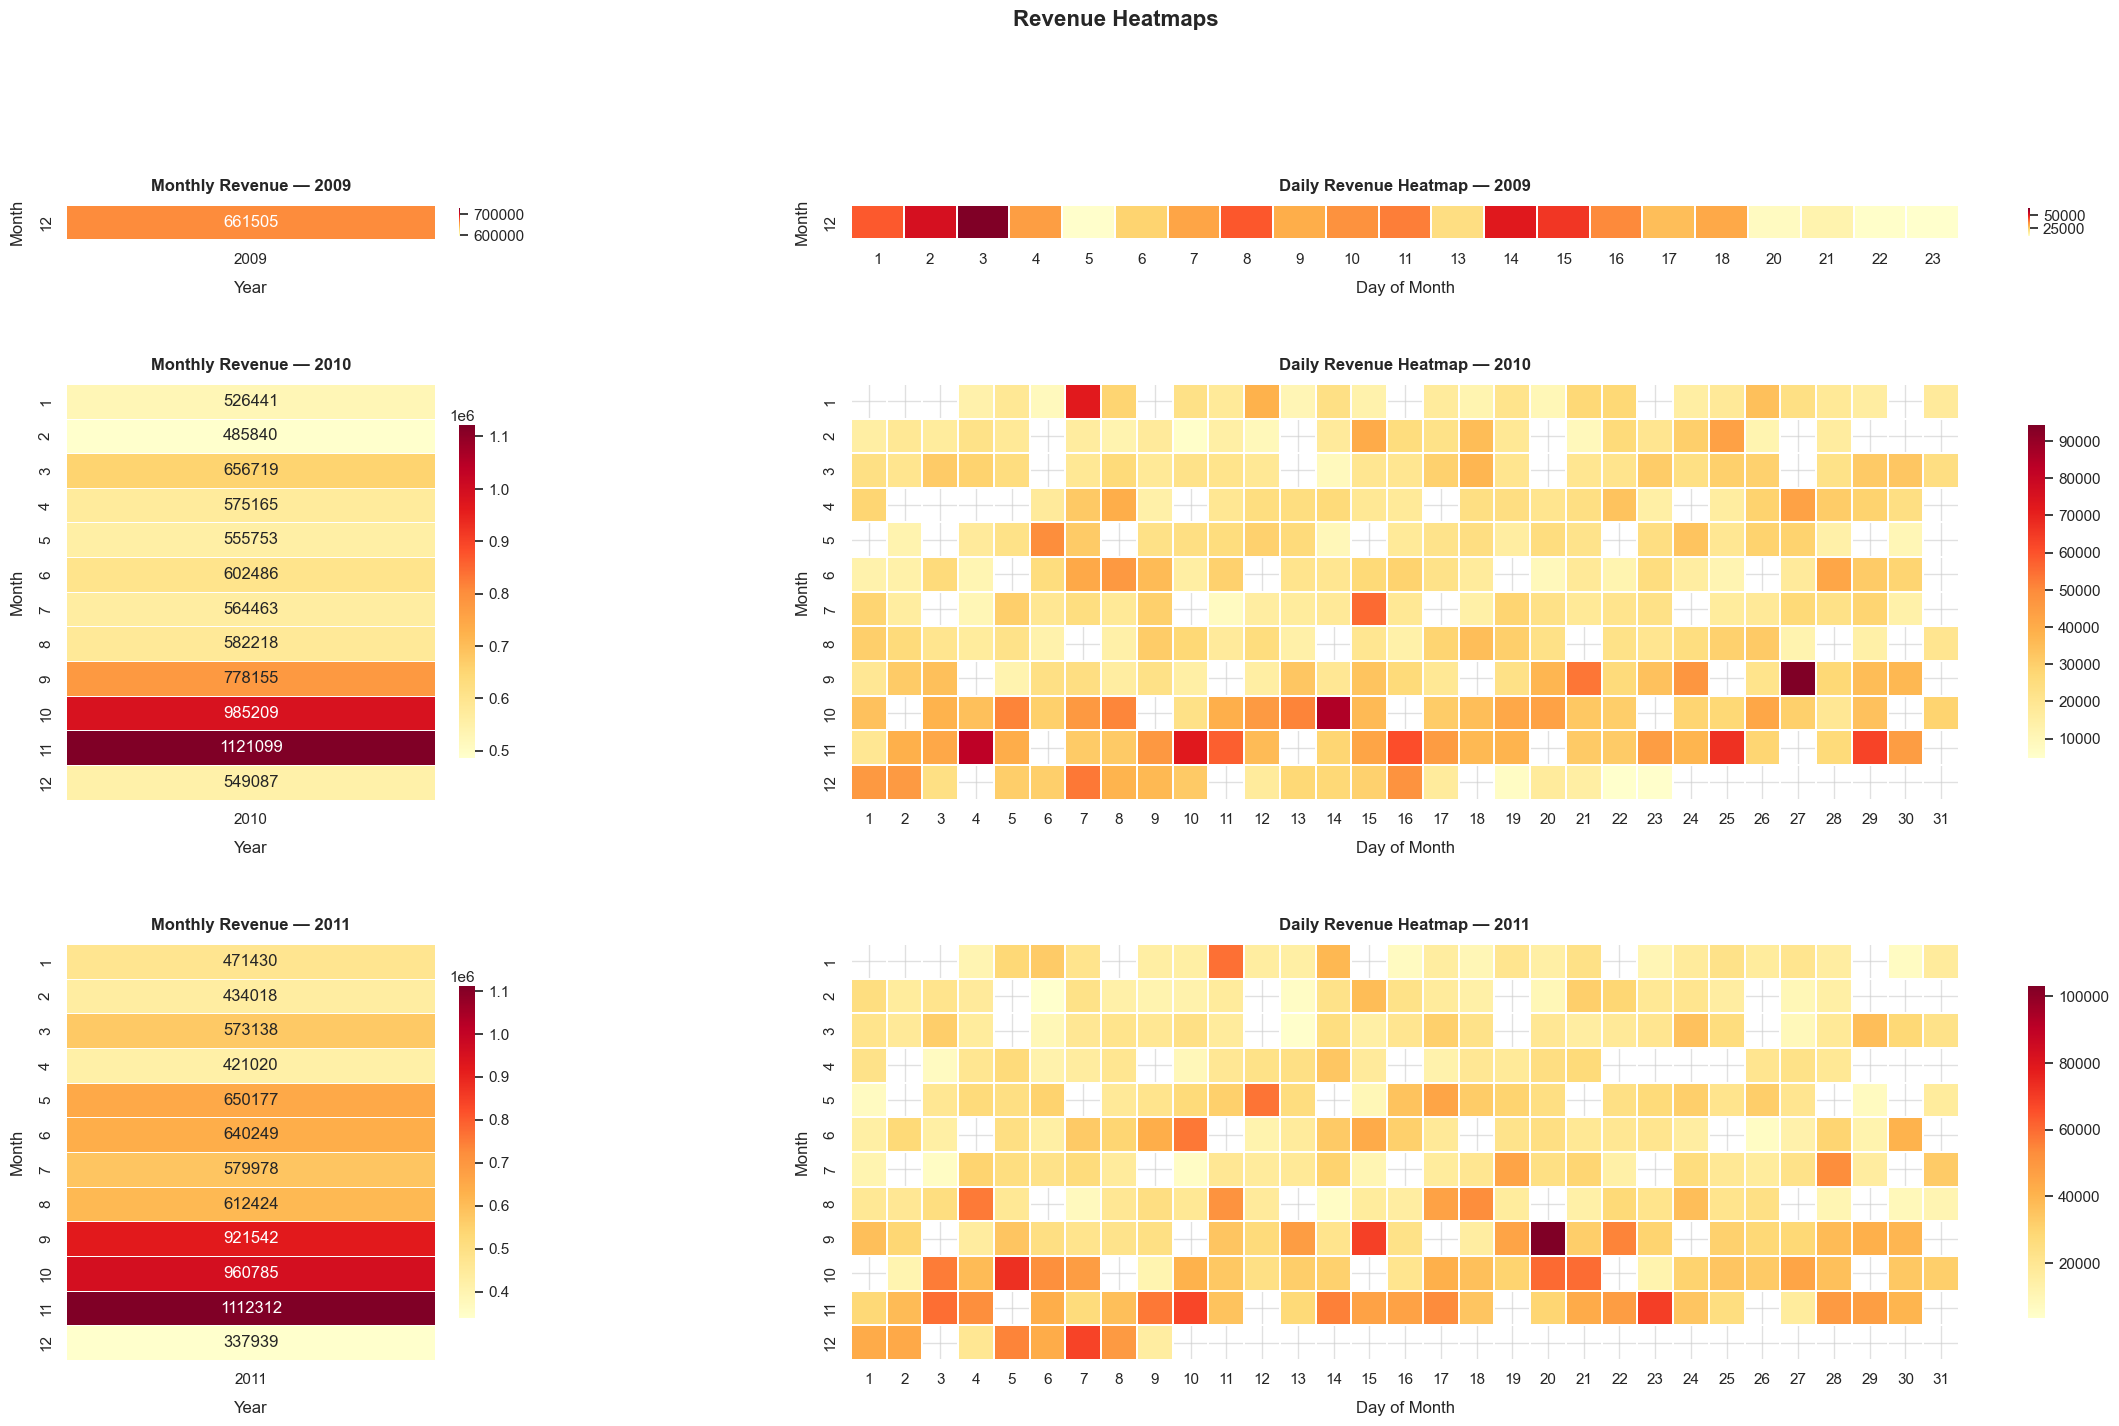

In [32]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

years = sorted(df['year'].unique())

# Count months per year for proportional row heights
month_counts = {year: df[df['year'] == year]['month'].nunique() for year in years}
height_ratios = [month_counts[y] for y in years]

pivot_rev = year_month_rev.pivot(index='month', columns='year', values='revenue')

fig = plt.figure(figsize=(28, sum(height_ratios) * 0.6))
gs = gridspec.GridSpec(
    len(years), 2,
    figure=fig,
    width_ratios=[0.6, 1.8],
    height_ratios=height_ratios,
    hspace=0.5,
    wspace=0.35
)

for i, year in enumerate(years):
    n_months = month_counts[year]

    # ── LEFT: monthly revenue bar-style heatmap ────────────────────────────────
    ax_left = fig.add_subplot(gs[i, 0])
    year_slice = pivot_rev[[year]].dropna()

    sns.heatmap(
        year_slice,
        annot=True,
        fmt=".0f",
        cmap="YlOrRd",
        linewidths=0.5,
        ax=ax_left,
        cbar=True,
        cbar_kws={'shrink': 0.8},
        yticklabels=year_slice.index  # only show months that exist
    )
    ax_left.set_title(f'Monthly Revenue — {year}', fontsize=12, fontweight='bold', pad=10)
    ax_left.set_xlabel('Year')
    ax_left.set_ylabel('Month')
    ax_left.tick_params(axis='x', rotation=0)

    # ── RIGHT: day-of-month heatmap ────────────────────────────────────────────
    ax_right = fig.add_subplot(gs[i, 1])

    year_data = df[df['year'] == year]
    pivot_day = (
        year_data
        .groupby(['month', 'day'])['revenue']
        .sum()
        .reset_index()
        .pivot(index='month', columns='day', values='revenue')
    )

    sns.heatmap(
        pivot_day,
        annot=False,
        cmap='YlOrRd',
        linewidths=0.3,
        ax=ax_right,
        cbar_kws={'shrink': 0.8},
        yticklabels=pivot_day.index  # only show months that exist
    )
    ax_right.set_title(f'Daily Revenue Heatmap — {year}', fontsize=12, fontweight='bold', pad=10)
    ax_right.set_xlabel('Day of Month')
    ax_right.set_ylabel('Month')

plt.suptitle('Revenue Heatmaps', fontsize=16, fontweight='bold', y=1.01)
plt.show()

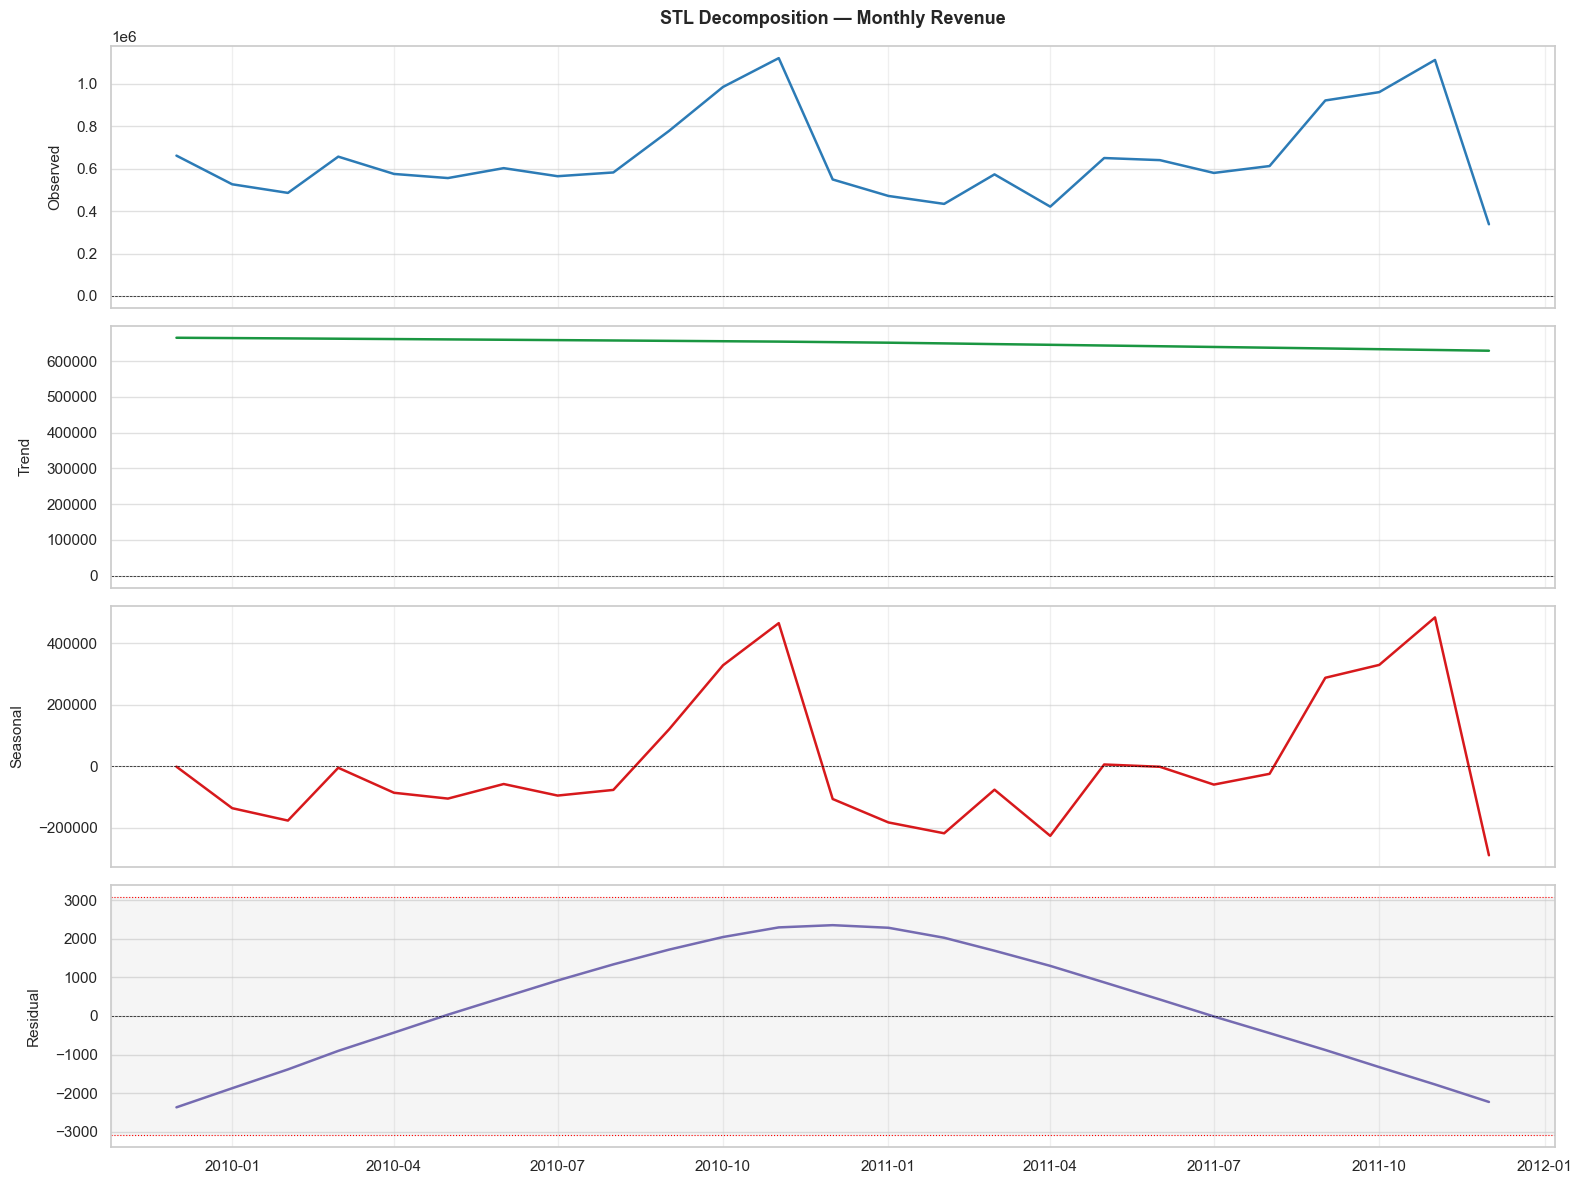

In [33]:
df['date'] = pd.to_datetime(df[['year', 'month', 'day']])

monthly = (
    df.groupby(['year', 'month'])['revenue']
    .sum()
    .reset_index()
    .sort_values(['year', 'month'])
)

ts = (
    monthly.set_index(pd.to_datetime(monthly[['year', 'month']].assign(day=1)))
    ['revenue']
    .asfreq('MS')
    .interpolate()
)

stl = STL(ts, period=12, robust=True)
res = stl.fit()

fig, axes = plt.subplots(4, 1, figsize=(16, 12), sharex=True)
components = {
    'Observed':   ts,
    'Trend':      res.trend,
    'Seasonal':   res.seasonal,
    'Residual':   res.resid,
}
colors = ['#2c7bb6', '#1a9641', '#d7191c', '#756bb1']

for ax, (label, series), color in zip(axes, components.items(), colors):
    ax.plot(series, color=color, linewidth=1.8)
    ax.set_ylabel(label, fontsize=11)
    ax.axhline(0, color='black', linewidth=0.5, linestyle='--')
    ax.grid(axis='x', alpha=0.3)

    if label == 'Residual':
        sigma = series.std()
        ax.axhspan(-2*sigma, 2*sigma, alpha=0.08, color='grey')
        ax.axhline(2*sigma,  color='red', linewidth=0.8, linestyle=':')
        ax.axhline(-2*sigma, color='red', linewidth=0.8, linestyle=':')

axes[0].set_title('STL Decomposition — Monthly Revenue', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

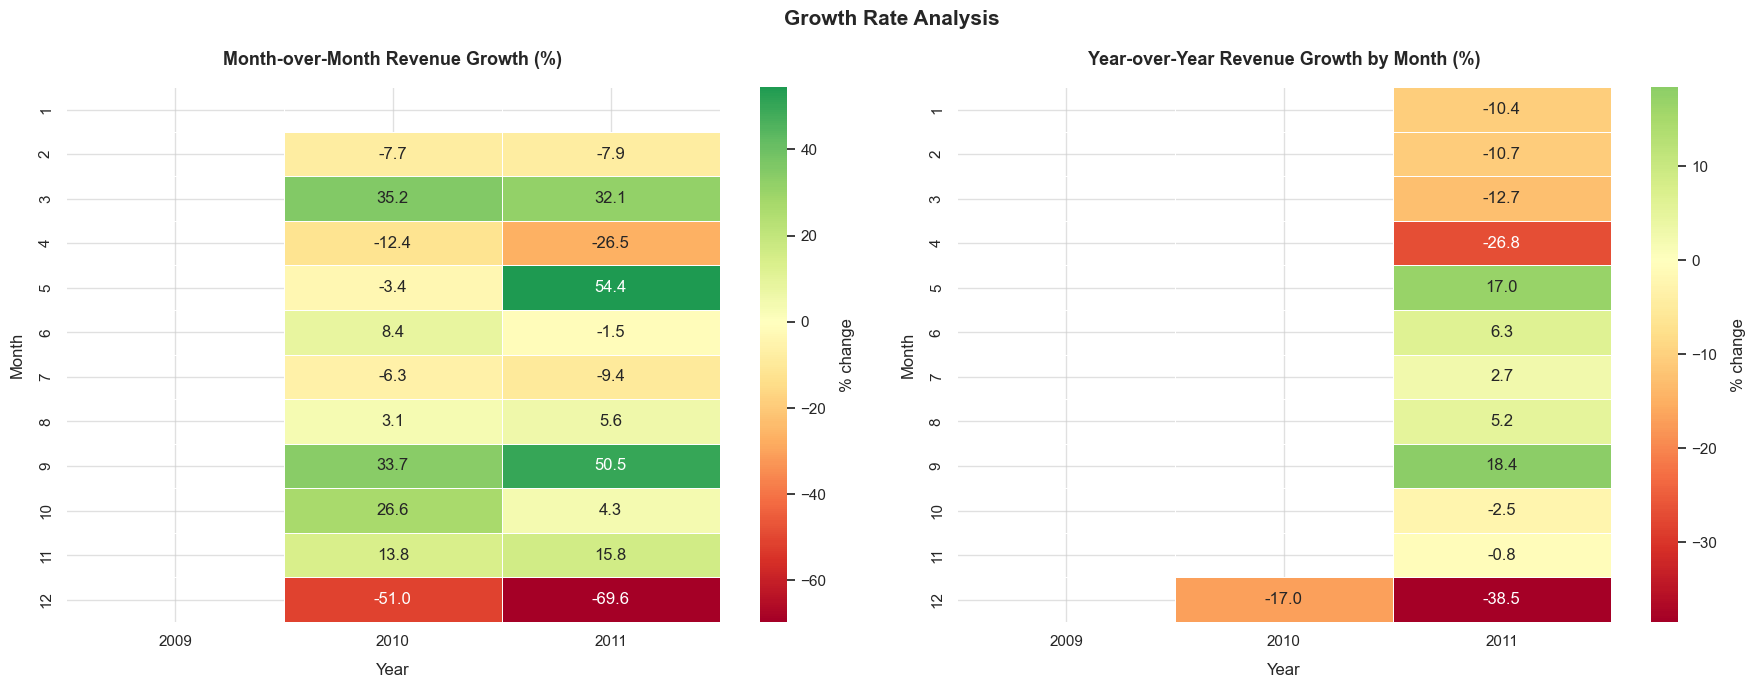

In [34]:
monthly['MoM'] = monthly.groupby('year')['revenue'].pct_change() * 100
monthly['YoY'] = monthly.groupby('month')['revenue'].pct_change() * 100

pivot_mom = monthly.pivot(index='month', columns='year', values='MoM')
pivot_yoy = monthly.pivot(index='month', columns='year', values='YoY')

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.heatmap(pivot_mom, annot=True, fmt=".1f", cmap="RdYlGn", center=0,
            linewidths=0.5, ax=axes[0], cbar_kws={'label': '% change'})
axes[0].set_title('Month-over-Month Revenue Growth (%)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Year'); axes[0].set_ylabel('Month')

sns.heatmap(pivot_yoy, annot=True, fmt=".1f", cmap="RdYlGn", center=0,
            linewidths=0.5, ax=axes[1], cbar_kws={'label': '% change'})
axes[1].set_title('Year-over-Year Revenue Growth by Month (%)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Year'); axes[1].set_ylabel('Month')

plt.suptitle('Growth Rate Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

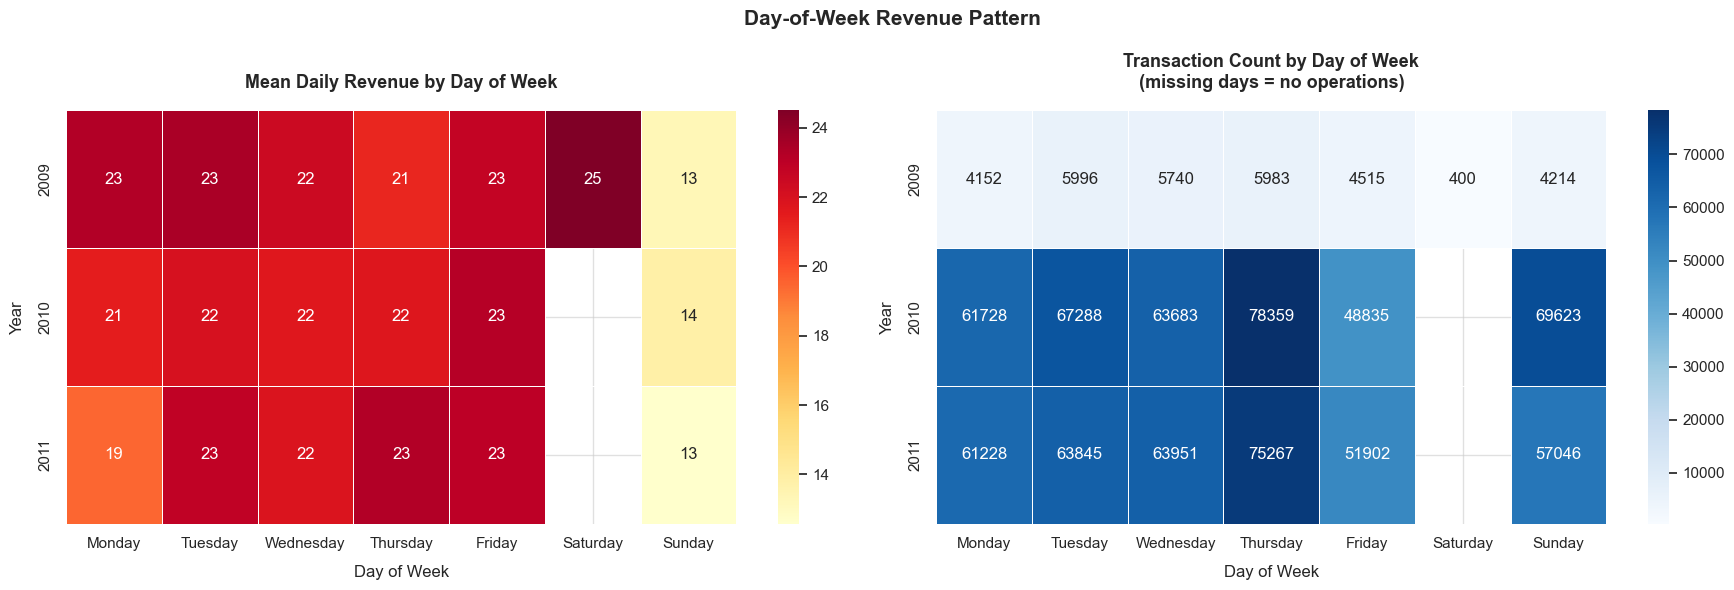

In [35]:
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow = (
    df.groupby(['year', 'day_of_week'])['revenue']
    .agg(['mean', 'sum', 'count'])
    .reset_index()
)
dow['day_of_week'] = pd.Categorical(dow['day_of_week'], categories=dow_order, ordered=True)
dow = dow.sort_values(['year', 'day_of_week'])

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Mean revenue per day-of-week (heatmap: year × dow)
pivot_dow_mean = dow.pivot(index='year', columns='day_of_week', values='mean')
sns.heatmap(pivot_dow_mean, annot=True, fmt=".0f", cmap="YlOrRd",
            linewidths=0.5, ax=axes[0])
axes[0].set_title('Mean Daily Revenue by Day of Week', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Day of Week'); axes[0].set_ylabel('Year')

# Transaction count heatmap to spot operational patterns
pivot_dow_count = dow.pivot(index='year', columns='day_of_week', values='count')
sns.heatmap(pivot_dow_count, annot=True, fmt=".0f", cmap="Blues",
            linewidths=0.5, ax=axes[1])
axes[1].set_title('Transaction Count by Day of Week\n(missing days = no operations)',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Day of Week'); axes[1].set_ylabel('Year')

plt.suptitle('Day-of-Week Revenue Pattern', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

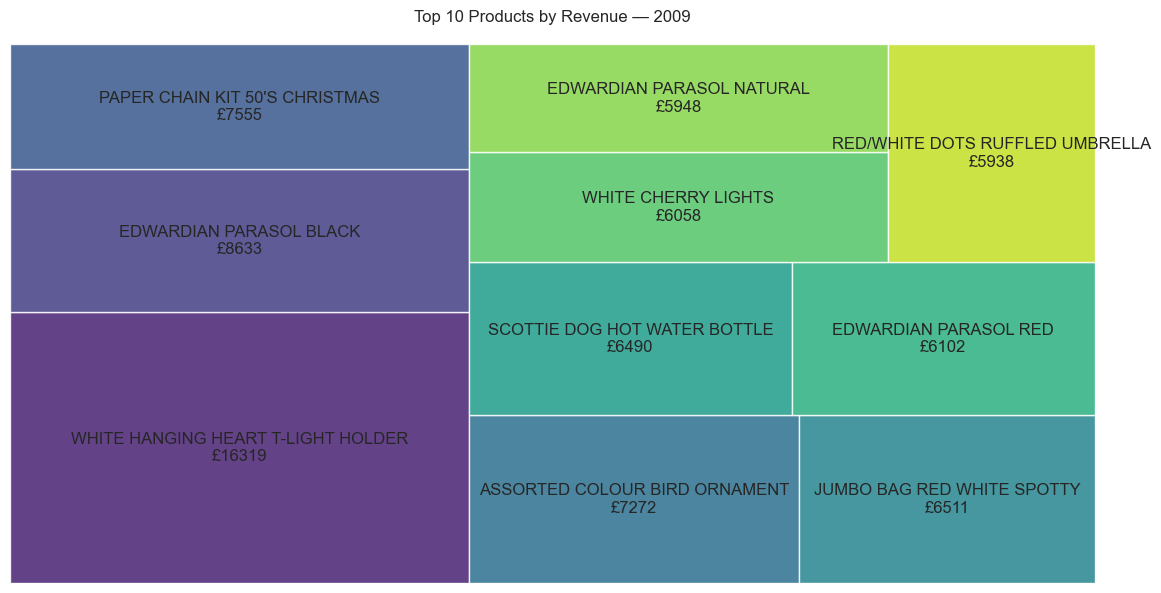

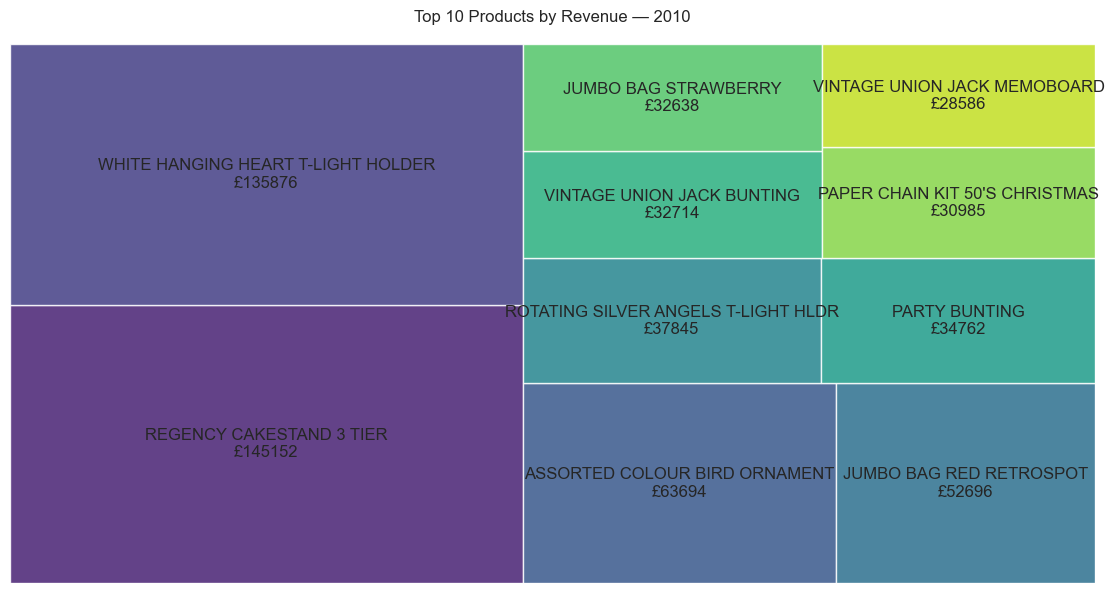

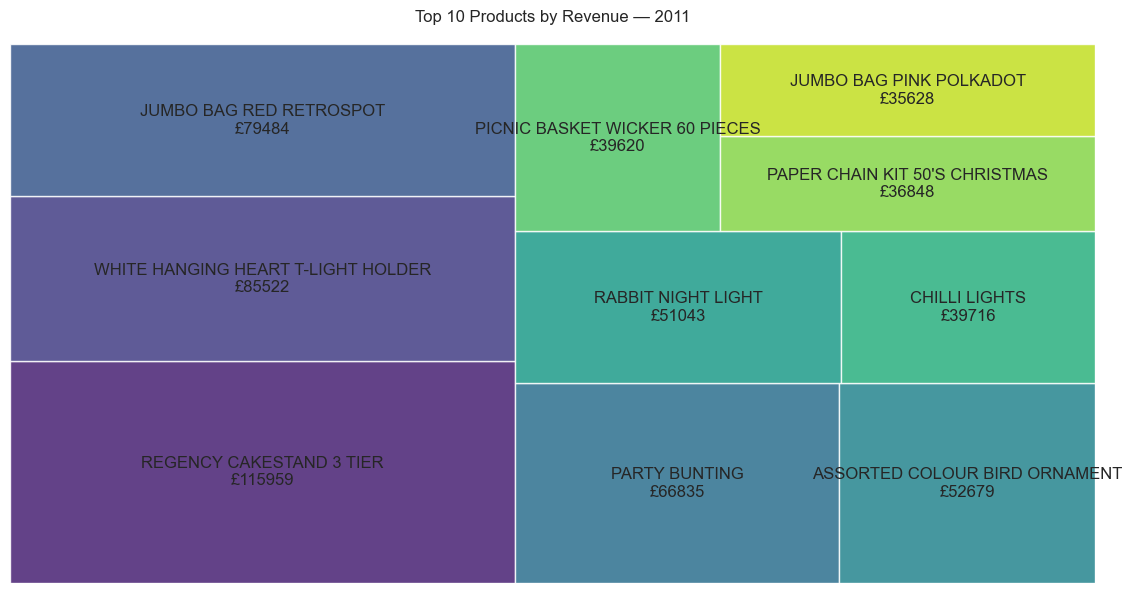

In [36]:
year_product_rev = df.groupby(['year', 'stock_code', 'description'])['revenue'].sum().reset_index()
year_product_rev = year_product_rev.sort_values(['year', 'revenue'], ascending=[True, False])

top_10_per_year = year_product_rev.groupby('year').head(10).reset_index()
top_10_per_year = top_10_per_year.drop(columns='index').copy()

for year in top_10_per_year['year'].unique():
    subset = top_10_per_year[top_10_per_year['year'] == year].sort_values('revenue', ascending=False)

    plt.figure(figsize=(14, 7))
    squarify.plot(
        sizes=subset['revenue'],
        label=subset['description'] + '\n£' + subset['revenue'].round(0).astype(int).astype(str),
        color=sns.color_palette('viridis', len(subset)),
        alpha=0.85
    )
    plt.title(f'Top 10 Products by Revenue — {year}')
    plt.axis('off')
    plt.show()

-  top 10 bestsellers per year, can be used in product analysis;

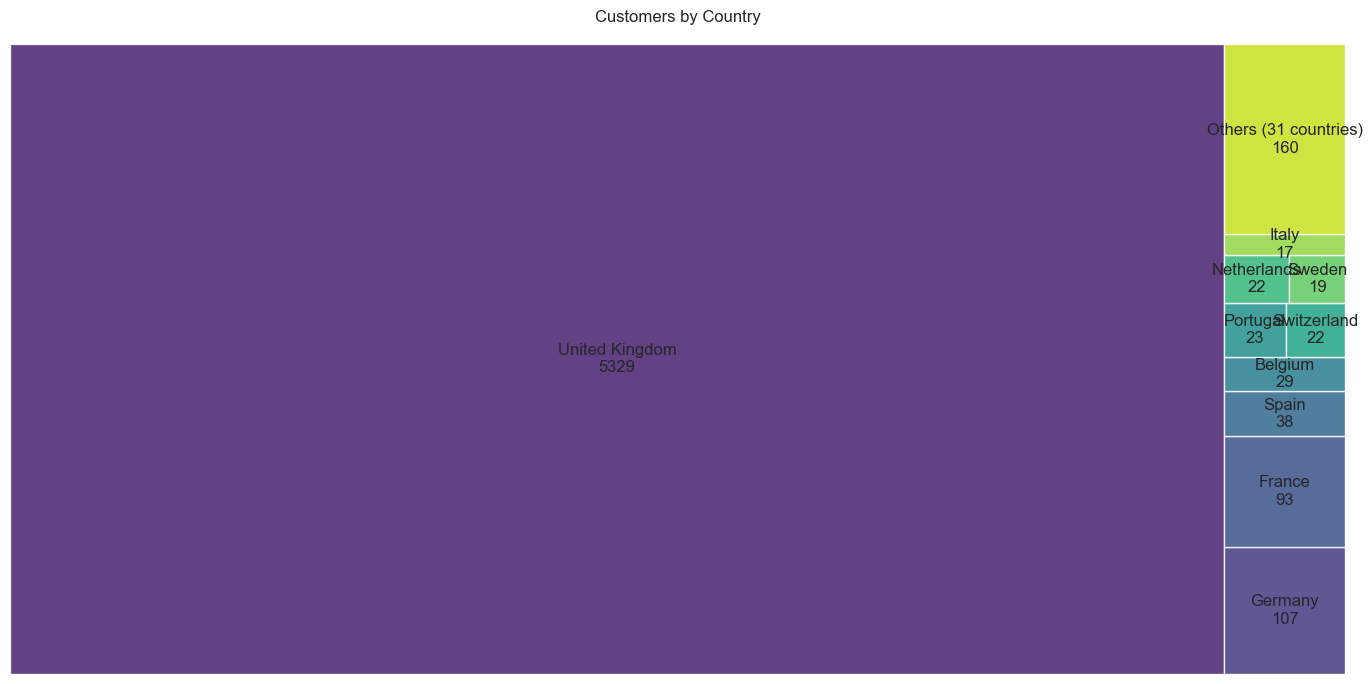

In [37]:
customer_unique = (
        df.groupby('country')['customer_id']
        .nunique()
        .reset_index()
        .sort_values('customer_id', ascending=False)
    )

total_countries = len(customer_unique)
top_n=10
year=None

if total_countries <= 30:
    plot_df = customer_unique.copy()
else:
    top = customer_unique.head(top_n)
    rest = customer_unique.iloc[top_n:]
    others_row = pd.DataFrame([{
        'country': f'Others ({len(rest)} countries)',
        'customer_id': rest['customer_id'].sum()
    }])
    plot_df = pd.concat([top, others_row], ignore_index=True)

plt.figure(figsize=(14, 7))
squarify.plot(
    sizes=plot_df['customer_id'],
    label=plot_df['country'] + '\n' + plot_df['customer_id'].astype(str),
    color=sns.color_palette('viridis', len(plot_df)),
    alpha=0.85,
)
title = 'Customers by Country'
if year:
    title += f' — {year}'
plt.title(title)
plt.axis('off')
plt.tight_layout()
plt.show()

- UK has 5329 unique customers, the biggest customer base, the second is Germany (107), followed by France (93), then Spain (38) and finally the others;

2026-04-26 13:06:12 | INFO    | matplotlib.category | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-04-26 13:06:12 | INFO    | matplotlib.category | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


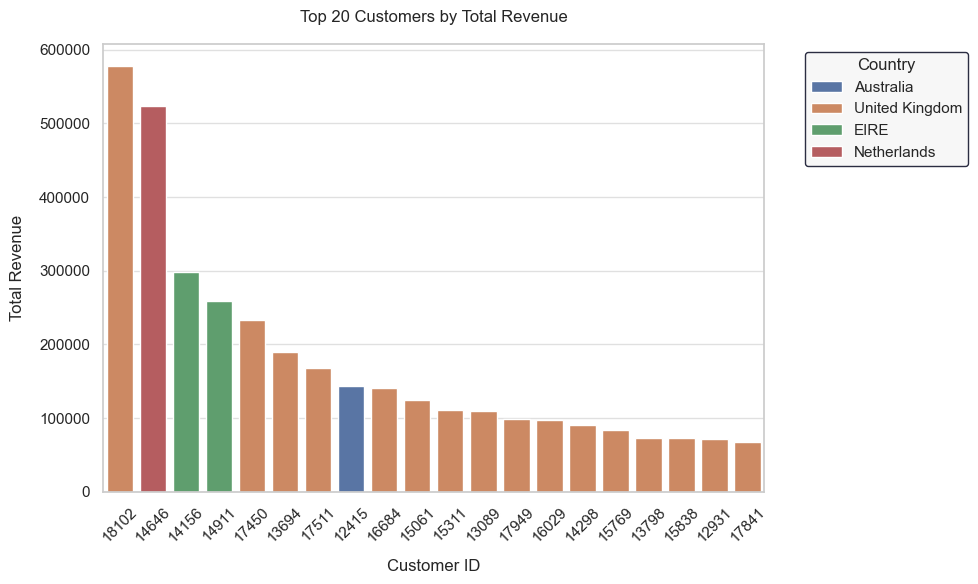

In [38]:
customers_revenue = df.groupby(['customer_id', 'country'])['revenue'].sum().reset_index()
sorted_data = customers_revenue.sort_values(by='revenue', ascending=False).head(20)

sns.barplot(
    x='customer_id', 
    y='revenue', 
    hue='country', 
    data=customers_revenue.sort_values(by='revenue', ascending=False).head(20),
    order=sorted_data['customer_id']
    )

plt.title('Top 20 Customers by Total Revenue')
plt.xlabel('Customer ID')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.legend(title='Country', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout() 
plt.show()

- 16 customers in top 20 are from UK, 2 from EIRE, 1 from Australia, 1 from Netherlands;
- very top customers from Netherlands, UK and EIRE are the most valuable, as they contribute to the revenue the most;
- even tough, the stable top customers also valuable, and loss of one will not contribute to a big revenue loss.

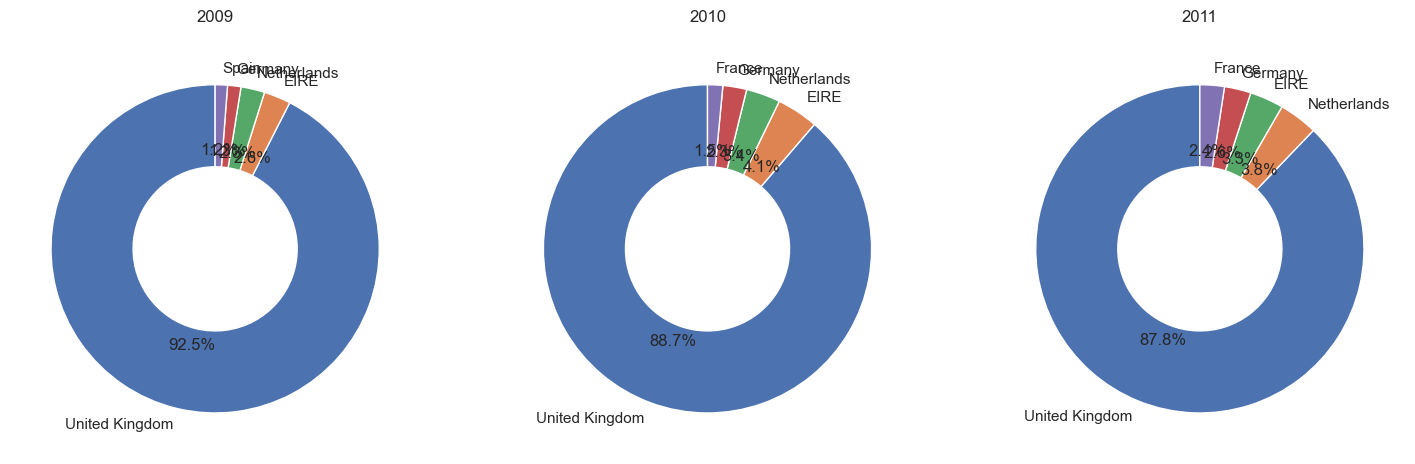

In [39]:
year_country_rev = (
    df.groupby(['year', 'country'])['revenue']
      .sum()
      .reset_index()
)

top_5_per_year = (
    year_country_rev
    .sort_values(['year', 'revenue'], ascending=[True, False])
    .groupby('year')
    .head(5)
)

years = sorted(top_5_per_year['year'].unique())
fig, axes = plt.subplots(1, len(years), figsize=(6 * len(years), 6))

if len(years) == 1:
    axes = [axes]

for ax, year in zip(axes, years):
    data_year = top_5_per_year[top_5_per_year['year'] == year]
    ax.pie(data_year['revenue'], labels=data_year['country'], autopct='%1.1f%%',
           startangle=90, wedgeprops=dict(width=0.5))  # <-- this makes it a donut
    ax.set_title(f'{year}')


- the money flow mostly comes from UK (approx. 88.5%); should consider segmentation separated for UK and Others;
- the share is shifting from the UK to other countires from 92.5% (only 1 month) to 88.7% and to 87.8%;

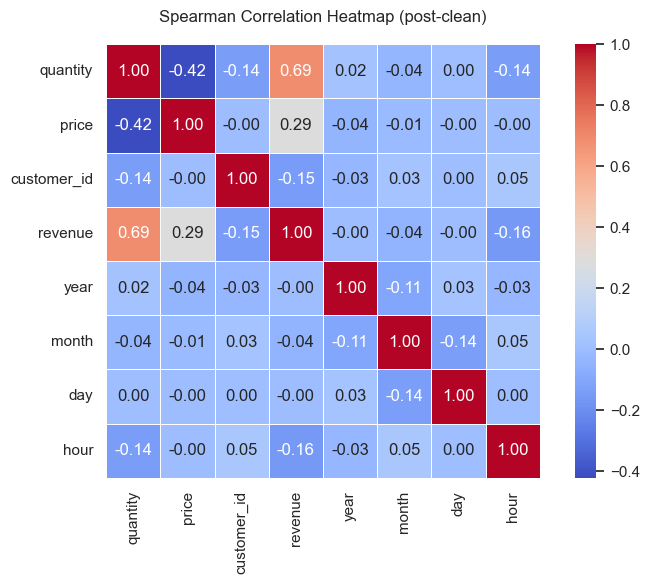

In [40]:
numeric_cols = df.select_dtypes(include='number').columns
corr = df[numeric_cols].corr(method='spearman')

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            square=True, linewidths=0.5, ax=ax)
ax.set_title('Spearman Correlation Heatmap (post-clean)')
plt.tight_layout()
plt.show()

- more money comes from qty (.69), rather than from price (.29), plus they have negative corr that proves the point (-.42)

In [41]:
df

,invoice,stock_code,description,quantity,invoice_date,price,customer_id,country,revenue,year,month,day,hour,day_of_week,date
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.950,13085,United Kingdom,83.400,2009,12,1,7,Tuesday,2009-12-01
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.750,13085,United Kingdom,81.000,2009,12,1,7,Tuesday,2009-12-01
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.750,13085,United Kingdom,81.000,2009,12,1,7,Tuesday,2009-12-01
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.100,13085,United Kingdom,100.800,2009,12,1,7,Tuesday,2009-12-01
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.250,13085,United Kingdom,30.000,2009,12,1,7,Tuesday,2009-12-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1067365,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.850,12680,France,10.200,2011,12,9,12,Friday,2011-12-09
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.100,12680,France,12.600,2011,12,9,12,Friday,2011-12-09
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.150,12680,France,16.600,2011,12,9,12,Friday,2011-12-09
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.150,12680,France,16.600,2011,12,9,12,Friday,2011-12-09


In [43]:
df.drop(columns=['day_of_week', 'date', 'day', 'hour'], inplace=True)

pd_to_csv_path = os.path.join('..', 'data', '02_processed', 'base_retail.csv')

os.makedirs(os.path.dirname(pd_to_csv_path), exist_ok=True)
df.to_csv(pd_to_csv_path, index=False)

print(f"Saved to: {pd_to_csv_path}")

Saved to: ..\data\02_processed\base_retail.csv


- saved processed base dataset for further feature engineering and eda;
- metadata is generated as it helps both humans and AI tools (in my case Copilot) understand schema;

## Summary of Initial EDA and Data Cleaning

### Key Data Quality Issues Identified:
- **22.8%** of customer IDs were missing (likely guest transactions)
- **0.4%** of product descriptions were missing  
- **34,000** duplicate records identified
- **23,000** entries with negative quantities (returns/cancellations)
- **6,000** entries with negative prices (data quality issues)
- Non-product transactions included (postage, fees, adjustments)

### Data Cleaning Steps Applied:
1. **Removed invalid transactions**: Zero/negative prices, non-product codes (POST, DOT, M, D, C2, etc.)
2. **Handled missing values**: Dropped records with missing customer IDs (cannot perform customer-level RFM without ID)
3. **Return/cancellation logic**: Invoice codes starting with 'C' indicate cancellations
4. **Revenue consistency**: Removed customers with negative total revenue balance
5. **Deduplication**: Removed 34k duplicate records
6. **Feature engineering**: Created `revenue` column (quantity × price), extracted `year` and `month`

### Key Insights:
- **Geographic concentration**: UK dominates with **~88.5%** of total revenue
- **Seasonality patterns**: Revenue spikes in **October-November** (pre-holiday surge), drops in December
- **Revenue drivers**: Quantity drives revenue more than price (correlation: 0.69 vs 0.29)
- **Price-quantity relationship**: **Negative correlation (-0.42)** suggests volume discounting
- **Dataset timespan**: December 2009 - December 2011 (2 full years)
- **Order behavior**: Median order size consistently 2-12 units across years

### Next Steps:
The cleaned dataset has been saved to `../data/02_processed/base_retail.csv` and is ready for:
1. RFM metric calculations & other feature engineering
2. Customer segmentation modeling

*Note: The dataset maintains both positive and negative quantities to preserve return/cancellation patterns for comprehensive customer behavior analysis.*